[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/geo-di-lab/emerge-lessons/blob/main/docs/ch1/lesson6.ipynb)

# Introduction to GLOBE Data
We will examine two GLOBE datasets: [Mosquito Habitat Mapper](https://observer.globe.gov/do-globe-observer/mosquito-habitats) and [Land Cover](https://observer.globe.gov/do-globe-observer/land-cover).

You can view an [interactive dashboard of this data](https://experience.arcgis.com/experience/15c3e38176ec44d1a2f250c218343b4b).

You can run the following code using Google Colab, which runs on your browser (no installations required).

First, we'll load the Python packages, which gives us more options with our code.

In [25]:
import pandas as pd                           # For working with data
pd.set_option("display.max_columns", None)    # Lets us see all columns of the data instead of just a preview
import geopandas as gpd                       # For working with spatial data
import numpy as np                            # For working with numbers
import matplotlib.pyplot as plt               # For making graphs
from datetime import date                     # For formatting dates
from PIL import Image                         # For getting and displaying images from links
import requests                               # For getting information from links
from io import BytesIO                        # For working with types of input and output

## Mosquito Habitat Mapper

We'll read a saved copy of the [GLOBE](https://www.globe.gov/globe-data/globe-api) data, stored as a GeoParquet file so that it loads quickly and reliably.

In [26]:
url = "https://github.com/geo-di-lab/geoemerge/raw/refs/heads/main/data/mosquito_habitat_mapper_orig.parquet"
data = gpd.read_parquet(BytesIO(requests.get(url).content))

If you get an error `NameError: name 'gpd' is not defined`, go to the top of this notebook and click the arrow next to the first code block starting with `import geopandas as gpd`. This will install the packages needed for the rest of the code.

**Optional: get the most recent data**

The file above is a saved copy of the GLOBE database, including data submitted up to August 2026. If you want the newest observations instead, you can download them directly from the GLOBE API.

1. Go to the [GLOBE API Interface](https://api.globe.gov/search/swagger-ui.html).
2. Click the second option, `GET /v1/measurement/protocol/measureddate/ Find measurements by protocol and measured date range.`
3. Click `Try it out` in the expanded section.
4. For "protocols" choose `mosquito_habitat_mapper`.
5. Enter your desired start and end date in the format Year-Month-Day (like 2026-08-31).
6. Set "geojson" to `TRUE`.
7. Set "sample" to `FALSE`.
8. Click `Execute` and wait for it to finish loading.
9. Scroll down to "Response body" and click `Download`.
10. Upload the file to this Google Colab page using the folder icon on the left.
11. Replace the cell above with the name of your file, in quotes like below, and re-run that cell.
```python
data = gpd.read_file("")
```

View the first 10 rows of the data, which are the most recently collected entries submitted to the GLOBE Observer App.

In [27]:
data.head(10)

,countryCode,countryName,elevation,mosquitohabitatmapperAbdomenCloseupPhotoUrls,mosquitohabitatmapperBreedingGroundEliminated,mosquitohabitatmapperComments,mosquitohabitatmapperDataSource,mosquitohabitatmapperExtraData,mosquitohabitatmapperGenus,mosquitohabitatmapperGlobeTeams,mosquitohabitatmapperLarvaFullBodyPhotoUrls,mosquitohabitatmapperLarvaeCount,mosquitohabitatmapperLastIdentifyStage,mosquitohabitatmapperLocationAccuracyM,mosquitohabitatmapperLocationMethod,mosquitohabitatmapperMeasuredAt,mosquitohabitatmapperMeasurementElevation,mosquitohabitatmapperMeasurementLatitude,mosquitohabitatmapperMeasurementLongitude,mosquitohabitatmapperMosquitoAdults,mosquitohabitatmapperMosquitoEggCount,mosquitohabitatmapperMosquitoEggs,mosquitohabitatmapperMosquitoHabitatMapperId,mosquitohabitatmapperMosquitoPupae,mosquitohabitatmapperSpecies,mosquitohabitatmapperUserid,mosquitohabitatmapperWaterSource,mosquitohabitatmapperWaterSourcePhotoUrls,mosquitohabitatmapperWaterSourceType,organizationId,organizationName,protocol,siteId,siteName,geometry
0,THA,Thailand,27.3,null,true,null,GLOBE Observer App,LarvaeVisibleNo,null,[Western GLOBE Community Thailand],null,0,null,4,automatic,2026-08-31 02:10:00,0,13.9537,99.6878,null,null,null,51237,false,null,183949365,"cement, metal or plastic tank",https://data.globe.gov/system/photos/2026/08/3...,container: artificial,106647949,Wat Wang Sala School,mosquito_habitat_mapper,424480,47PNR742427,POINT (99.68694 13.95358)
1,GTM,Guatemala,1494.9,null,true,null,GLOBE Observer App,LarvaeVisibleNo,null,"[CENCAR, dominicana2, EMERGE GEO DI Guatemala,...",null,0,null,128,automatic,2026-08-29 20:28:00,0,14.5977,-90.5589,null,null,null,51235,false,null,12781123,plant clumps (bamboo etc),null,container: natural,112712735,STEAM Program Guatemala,mosquito_habitat_mapper,324426,15PYS629152,POINT (-90.55974 14.59732)
2,TUR,Turkey,4.2,null,true,null,GLOBE Observer App,LarvaeVisibleNo,null,NaN,null,0,null,11,automatic,2026-08-29 11:20:00,0,39.1478,26.8284,null,null,null,51233,false,null,193050607,discarded: other,https://data.globe.gov/system/photos/2026/08/2...,container: artificial,17542446,Turkey Citizen Science,mosquito_habitat_mapper,424761,35SMD851331,POINT (26.82757 39.14697)
3,USA,United States,95.9,null,false,Active fish feeding,GLOBE Observer App,LarvaeVisibleNo,null,[Midlands Overwatch ],null,0,null,3,automatic,2026-08-28 15:29:00,0,34.1429,-80.9579,null,null,null,51228,false,null,161454935,"puddle or still water next to a creek, stream ...",null,flowing: still water found next to river or st...,17043304,United States of America Citizen Science,mosquito_habitat_mapper,419154,17SNT038780,POINT (-80.95878 34.14289)
4,IND,India,25.4,null,true,null,GLOBE Observer App,LarvaeVisibleNo,null,NaN,null,0,null,38,automatic,2026-08-28 11:26:00,0,19.2038,72.9821,null,null,null,51225,false,null,193290387,"puddle, vehicle or animal tracks",null,still: lake/pond/swamp,17179766,India Citizen Science,mosquito_habitat_mapper,424695,43QBB878246,POINT (72.98171 19.20373)
5,USA,United States,106.2,null,false,null,GLOBE Observer App,LarvaeVisibleNo,null,[Midlands Overwatch ],null,0,null,3,automatic,2026-08-28 16:19:00,0,34.1443,-80.9579,null,null,null,51230,false,null,161454935,pond,null,still: lake/pond/swamp,17043304,United States of America Citizen Science,mosquito_habitat_mapper,419155,17SNT038781,POINT (-80.95878 34.14379)
6,GTM,Guatemala,1519.3,null,false,null,GLOBE Observer App,LarvaeVisibleYes,null,[EMERGE GEO DI Guatemala],https://data.globe.gov/system/photos/2026/08/2...,4000,identify-siphon-pecten,15,automatic,2026-08-28 23:58:00,0,14.6279,-90.5374,true,null,true,51232,true,null,190813680,adult mosquito trap,https://data.globe.gov/system/photos/2026/08/2...,container: artificial,19879312,Guatemala Citizen Science,mosquito_habitat_mapper,424749,15PYS652186,POINT (-90.53807 14.62781)
7,THA,Thailand,10.4,null,true,null,GLOBE Observer App,LarvaeVisibleYes,null,NaN,null,15,identify,48,automatic,2026-08-28 03:41:00,0,8.5253,99.

Let's use the `info()` function to learn more about what the dataset contains.

In [28]:
data.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 49464 entries, 0 to 49463
Data columns (total 35 columns):
 #   Column                                         Non-Null Count  Dtype         
---  ------                                         --------------  -----         
 0   countryCode                                    49378 non-null  str           
 1   countryName                                    49378 non-null  str           
 2   elevation                                      49464 non-null  str           
 3   mosquitohabitatmapperAbdomenCloseupPhotoUrls   49464 non-null  str           
 4   mosquitohabitatmapperBreedingGroundEliminated  49464 non-null  str           
 5   mosquitohabitatmapperComments                  49464 non-null  str           
 6   mosquitohabitatmapperDataSource                49464 non-null  str           
 7   mosquitohabitatmapperExtraData                 49464 non-null  str           
 8   mosquitohabitatmapperGenus                     4

We see information about each column, how many non-null rows there are (non-null means not missing), and the type (a dtype of "object" means it is text). We see that we also have a `datetime` column, which would be great for analyzing the data over time. The `geometry` column gives us information about where the citizen scientist collected the data about mosquitoes.

However, there are some columns that are currently stored as an "object" when we want then to be stored as a "float" (decimal) or "int" (whole number). Also, for some rows, if the value is missing, there is the word "null," which can be confused as an actual value. We'll replace this with NAN, which Python reads as empty rather than an object.

Note: The column 'mosquitohabitatmapperLarvaeCount' stores numbers in addition to ranges like 1-25. However, we need to simplify these ranges to a single number to make them easier to store in the dataset and more consistent. So, if there is a range, we will replace it with the lower value of the range.

In [29]:
# Let's remove the "mosquitomapper" in front of all the column names to make it easier to see the names
new_column_names = data.columns.str.replace("mosquitohabitatmapper", "")

# Make the first letter of each column name capitalized (for consistency) except for geometry
new_column_names = [name[0].upper() + name[1:] if name != 'geometry' else name for name in new_column_names]

data.columns = new_column_names
data.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 49464 entries, 0 to 49463
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   CountryCode               49378 non-null  str           
 1   CountryName               49378 non-null  str           
 2   Elevation                 49464 non-null  str           
 3   AbdomenCloseupPhotoUrls   49464 non-null  str           
 4   BreedingGroundEliminated  49464 non-null  str           
 5   Comments                  49464 non-null  str           
 6   DataSource                49464 non-null  str           
 7   ExtraData                 49464 non-null  str           
 8   Genus                     49464 non-null  str           
 9   GlobeTeams                18279 non-null  str           
 10  LarvaFullBodyPhotoUrls    49464 non-null  str           
 11  LarvaeCount               49464 non-null  str           
 12  LastIdenti

In [30]:
# Add new column for date, not including the time
data['MeasuredDate'] = data['MeasuredAt'].dt.date

In [31]:
# The LarvaeCount column has some grouped entries like '1-25' that we will replace with the center value
data['LarvaeCountProcessed'] = data['LarvaeCount'].replace({
    '1-25': 13,
    '26-50': 38,
    '51-100': 76,
    'more than 100': 100,
    'null': np.nan
})

# If the LarvaeCount is very long (more than 10 characters), then it is likely an error, so we'll replace with NAN
data.loc[data['LarvaeCountProcessed'].str.len() > 10, 'LarvaeCountProcessed'] = np.nan

numeric_cols = ['LarvaeCountProcessed', 'MeasurementLatitude', 'MeasurementLongitude']
data[numeric_cols] = data[numeric_cols].apply(pd.to_numeric)

# Drop the MosquitoEggCount column because it is all null
data = data.drop(columns=['MosquitoEggCount'])

# Replace the word 'null' with NAN to ensure it is stored as an empty value instead of a word
data = data.replace('null', np.nan)

data.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 49464 entries, 0 to 49463
Data columns (total 36 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   CountryCode               49378 non-null  str           
 1   CountryName               49378 non-null  str           
 2   Elevation                 49464 non-null  str           
 3   AbdomenCloseupPhotoUrls   1005 non-null   str           
 4   BreedingGroundEliminated  49403 non-null  str           
 5   Comments                  4725 non-null   str           
 6   DataSource                49464 non-null  str           
 7   ExtraData                 17029 non-null  str           
 8   Genus                     4837 non-null   str           
 9   GlobeTeams                18279 non-null  str           
 10  LarvaFullBodyPhotoUrls    9422 non-null   str           
 11  LarvaeCount               29327 non-null  str           
 12  LastIdenti

The final data cleaning step we will perform for now is to remove points that have invalid coordinates. Sometimes, the latitude and longitude may be incorrectly reported, placing the point at the middle of the ocean. We want to remove any points that are not on land. To do that, let's load a publicly-available file of country boundaries. The country boundaries (excluding Antarctica) were downloaded from [ArcGIS Data and Maps](https://hub.arcgis.com/datasets/esri::world-countries/explore).

<Axes: >

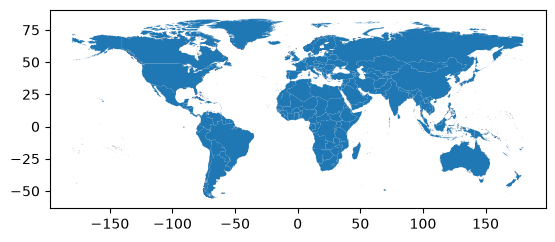

In [32]:
countries = gpd.read_file('https://github.com/geo-di-lab/emerge-lessons/raw/refs/heads/main/docs/data/world_countries.zip')[['COUNTRY', 'geometry']].to_crs(4326)
countries.plot()

We will use a [spatial join](https://geopandas.org/en/stable/docs/reference/api/geopandas.sjoin.html) (`sjoin`) to get all of the data that "intersects" the countries layer, meaning it is either within or on the boundary of a country.

In [33]:
data = gpd.sjoin(data, countries, how="inner", predicate='intersects') \
          .drop(columns=['index_right', 'COUNTRY']) \
          .reset_index(drop=True)

In [34]:
data

,CountryCode,CountryName,Elevation,AbdomenCloseupPhotoUrls,BreedingGroundEliminated,Comments,DataSource,ExtraData,Genus,GlobeTeams,LarvaFullBodyPhotoUrls,LarvaeCount,LastIdentifyStage,LocationAccuracyM,LocationMethod,MeasuredAt,MeasurementElevation,MeasurementLatitude,MeasurementLongitude,MosquitoAdults,MosquitoEggs,MosquitoHabitatMapperId,MosquitoPupae,Species,Userid,WaterSource,WaterSourcePhotoUrls,WaterSourceType,OrganizationId,OrganizationName,Protocol,SiteId,SiteName,geometry,MeasuredDate,LarvaeCountProcessed
0,THA,Thailand,27.3,NaN,true,NaN,GLOBE Observer App,LarvaeVisibleNo,NaN,[Western GLOBE Community Thailand],NaN,0,NaN,4,automatic,2026-08-31 02:10:00,0,13.953700,99.687800,NaN,NaN,51237,false,NaN,183949365,"cement, metal or plastic tank",https://data.globe.gov/system/photos/2026/08/3...,container: artificial,106647949,Wat Wang Sala School,mosquito_habitat_mapper,424480,47PNR742427,POINT (99.68694 13.95358),2026-08-31,0.0
1,GTM,Guatemala,1494.9,NaN,true,NaN,GLOBE Observer App,LarvaeVisibleNo,NaN,"[CENCAR, dominicana2, EMERGE GEO DI Guatemala,...",NaN,0,NaN,128,automatic,2026-08-29 20:28:00,0,14.597700,-90.558900,NaN,NaN,51235,false,NaN,12781123,plant clumps (bamboo etc),NaN,container: natural,112712735,STEAM Program Guatemala,mosquito_habitat_mapper,324426,15PYS629152,POINT (-90.55974 14.59732),2026-08-29,0.0
2,TUR,Turkey,4.2,NaN,true,NaN,GLOBE Observer App,LarvaeVisibleNo,NaN,NaN,NaN,0,NaN,11,automatic,2026-08-29 11:20:00,0,39.147800,26.828400,NaN,NaN,51233,false,NaN,193050607,discarded: other,https://data.globe.gov/system/photos/2026/08/2...,container: artificial,17542446,Turkey Citizen Science,mosquito_habitat_mapper,424761,35SMD851331,POINT (26.82757 39.14697),2026-08-29,0.0
3,USA,United States,95.9,NaN,false,Active fish feeding,GLOBE Observer App,LarvaeVisibleNo,NaN,[Midlands Overwatch ],NaN,0,NaN,3,automatic,2026-08-28 15:29:00,0,34.142900,-80.957900,NaN,NaN,51228,false,NaN,161454935,"puddle or still water next to a creek, stream ...",NaN,flowing: still water found next to river or st...,17043304,United States of America Citizen Science,mosquito_habitat_mapper,419154,17SNT038780,POINT (-80.95878 34.14289),2026-08-28,0.0
4,IND,India,25.4,NaN,true,NaN,GLOBE Observer App,LarvaeVisibleNo,NaN,NaN,NaN,0,NaN,38,automatic,2026-08-28 11:26:00,0,19.203800,72.982100,NaN,NaN,51225,false,NaN,193290387,"puddle, vehicle or animal tracks",NaN,still: lake/pond/swamp,17179766,India Citizen Science,mosquito_habitat_mapper,424695,43QBB878246,POINT (72.98171 19.20373),2026-08-28,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49039,USA,United States,485.3,NaN,false,NaN,GLOBE Observer App,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2017-05-29 19:08:00,485.3,34.124374,-117.749344,NaN,NaN,4,NaN,NaN,11114,fountain or bird bath,https://data.globe.gov/system/photos/2017/05/2...,container: artificial,12993805,Canyon Weather,mosquito_habitat_mapper,35802,11SMT309762,POINT (-117.74934 34.12437),2017-05-29,NaN
49040,USA,United States,467.6,NaN,true,NaN,GLOBE Observer App,NaN,NaN,NaN,NaN,0,identify,NaN,NaN,2017-05-29 19:12:00,467.6,34.123473,-117.749336,false,false,6,false,NaN,11114,"cement, metal or plastic tank",https://data.globe.gov/system/photos/2017/05/2...,container: artificial,12993805,Canyon Weather,mosquito_habitat_mapper,35822,11SMT309761,POINT (-117.74934 34.12347),2017-05-29,0.0
49041,USA,United States,467.6,NaN,true,NaN,GLOBE Observer App,NaN,NaN,NaN,NaN,0,identify-siphon-pecten,NaN,NaN,2017-05-29 19:10:00,467.6,34.123473,-117.749336,false,false,5,false,NaN,11114,fountain or bird bath,https://data.globe.gov/system/photos/2017/05/2...,container: artificial,12993805,Canyon Weather,mosquito_habitat_mapper,35822,11SMT309761,POINT (-117.74934 34.12347),2017-05-29,0.0
49042,USA,United States,74.5,NaN,true,NaN,GLOBE Observer App,NaN,NaN,NaN,NaN,0,identify,NaN,NaN,2017-05-29 20:30:00,74.5,38.857788,-77.153990,true,false,7,false,NaN,6972382,dish or 

A copy of this dataset is [on GitHub](https://github.com/geo-di-lab/geoemerge/tree/main/data), and we will use this in future chapters. You do not need to download the dataset to your computer, as we will load the data directly using the link.

### Explore the Data

Let's make a simple graph showing the number of contributions submitted by citizen scientists over time!

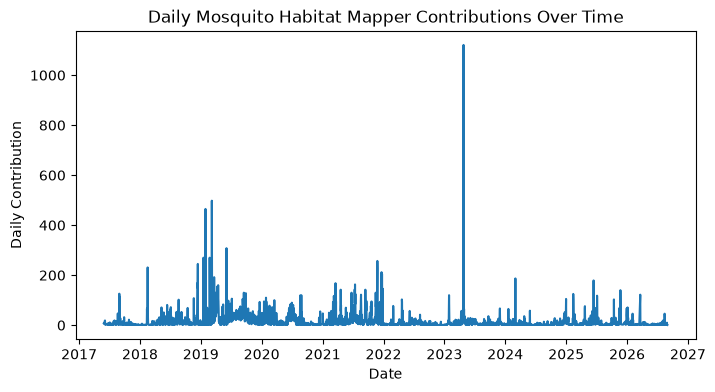

In [35]:
data_by_day = data[['SiteId', 'MeasuredDate']].groupby(['MeasuredDate'], as_index=False).count()

plt.figure(figsize=(8,4))
plt.plot(data_by_day['MeasuredDate'], data_by_day['SiteId'])
plt.xlabel("Date")
plt.ylabel("Daily Contribution")
plt.title("Daily Mosquito Habitat Mapper Contributions Over Time")
plt.show()

Let's plot the number of contributions by country:

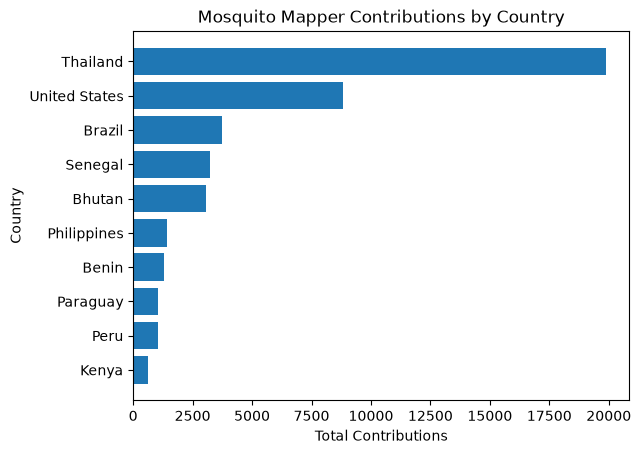

In [36]:
data_by_county = data[['SiteId', 'CountryName']].groupby(['CountryName'], as_index=False).count().sort_values(by='SiteId').tail(10)

plt.barh(data_by_county['CountryName'], data_by_county['SiteId'])
plt.xlabel("Total Contributions")
plt.ylabel("Country")
plt.title("Mosquito Mapper Contributions by Country")
plt.show()

## Land Cover

Now, we'll review the Land Cover dataset. We'll load it in the same way as the Mosquito dataset.

In [37]:
url = "https://github.com/geo-di-lab/geoemerge/raw/refs/heads/main/data/land_covers_orig.parquet"
data = gpd.read_parquet(BytesIO(requests.get(url).content))

**Optional: get the most recent data**

The file above is a saved copy of the GLOBE database, including data submitted up to August 2026. If you want the newest observations instead, you can download them directly from the GLOBE API.

1. Go to the [GLOBE API Interface](https://api.globe.gov/search/swagger-ui.html).
2. Click the second option, `GET /v1/measurement/protocol/measureddate/ Find measurements by protocol and measured date range.`
3. Click `Try it out` in the expanded section.
4. For "protocols" choose `land_covers`.
5. Enter your desired start and end date in the format Year-Month-Day (like 2026-08-31).
6. Set "geojson" to `TRUE`.
7. Set "sample" to `FALSE`.
8. Click `Execute` and wait for it to finish loading.
9. Scroll down to "Response body" and click `Download`.
10. Upload the file to this Google Colab page using the folder icon on the left.
11. Replace the cell above with the name of your file, in quotes like below, and re-run that cell.
```python
data = gpd.read_file("")
```

View a list of the columns in the dataset:

In [38]:
data.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 67936 entries, 0 to 67935
Data columns (total 63 columns):
 #   Column                          Non-Null Count  Dtype         
---  ------                          --------------  -----         
 0   countryCode                     67901 non-null  str           
 1   countryName                     67901 non-null  str           
 2   elevation                       67936 non-null  str           
 3   landcoversDataSource            67936 non-null  str           
 4   landcoversDownwardCaption       67936 non-null  str           
 5   landcoversDownwardExtraData     67936 non-null  str           
 6   landcoversDownwardPhotoUrl      67936 non-null  str           
 7   landcoversDryGround             67936 non-null  str           
 8   landcoversEastCaption           67936 non-null  str           
 9   landcoversEastClassifications   67936 non-null  str           
 10  landcoversEastExtraData         67936 non-null  str           

In [39]:
# Let's remove the "landcovers" in front of all the column names to make it easier to see the names
new_column_names = data.columns.str.replace("landcovers", "")

# Make the first letter of each column name capitalized (for consistency) except for geometry
new_column_names = [name[0].upper() + name[1:] if name != 'geometry' else name for name in new_column_names]

data.columns = new_column_names
data.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 67936 entries, 0 to 67935
Data columns (total 63 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   CountryCode           67901 non-null  str           
 1   CountryName           67901 non-null  str           
 2   Elevation             67936 non-null  str           
 3   DataSource            67936 non-null  str           
 4   DownwardCaption       67936 non-null  str           
 5   DownwardExtraData     67936 non-null  str           
 6   DownwardPhotoUrl      67936 non-null  str           
 7   DryGround             67936 non-null  str           
 8   EastCaption           67936 non-null  str           
 9   EastClassifications   67936 non-null  str           
 10  EastExtraData         67936 non-null  str           
 11  EastPhotoUrl          67936 non-null  str           
 12  Feature1Caption       67936 non-null  str           
 13  Feature1

In [40]:
# Add new column for date
data['MeasuredDate'] = data['MeasuredAt'].dt.date

data.head(10)

,CountryCode,CountryName,Elevation,DataSource,DownwardCaption,DownwardExtraData,DownwardPhotoUrl,DryGround,EastCaption,EastClassifications,EastExtraData,EastPhotoUrl,Feature1Caption,Feature1ExtraData,Feature1PhotoUrl,Feature2Caption,Feature2ExtraData,Feature2PhotoUrl,Feature3Caption,Feature3ExtraData,Feature3PhotoUrl,Feature4Caption,Feature4ExtraData,Feature4PhotoUrl,FieldNotes,GlobeTeams,LandCoverId,LeavesOnTrees,LocationAccuracyM,LocationMethod,MeasuredAt,MeasurementElevation,MeasurementLatitude,MeasurementLongitude,MucCode,MucDescription,MucDetails,Muddy,NorthCaption,NorthClassifications,NorthExtraData,NorthPhotoUrl,RainingSnowing,SnowIce,SouthCaption,SouthClassifications,SouthExtraData,SouthPhotoUrl,StandingWater,UpwardCaption,UpwardExtraData,UpwardPhotoUrl,Userid,WestCaption,WestClassifications,WestExtraData,WestPhotoUrl,OrganizationId,OrganizationName,Protocol,SiteId,SiteName,geometry,MeasuredDate
0,USA,United States,5.1,GLOBE Observer App,null,null,https://data.globe.gov/system/photos/2026/08/3...,true,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,(none),[IEOPCNP],94653,true,1414,automatic,2026-08-31 15:55:00,4.9,40.0199,-75.0422,null,null,,false,null,null,null,https://data.globe.gov/system/photos/2026/08/3...,false,false,null,null,null,null,false,null,null,https://data.globe.gov/system/photos/2026/08/3...,2514462,null,null,null,https://data.globe.gov/system/photos/2026/08/3...,2620510,Institute for Earth Observations School,land_covers,424899,18TVK963299,POINT (-75.04336 40.0193),2026-08-31
1,USA,United States,235.5,GLOBE Observer App,null,null,https://data.globe.gov/system/photos/2026/08/3...,false,null,"10% MUC 11 (n) [Trees, Loosely Spaced, Evergre...",null,https://data.globe.gov/system/photos/2026/08/3...,null,null,null,null,null,null,null,null,null,null,null,null,(none),NaN,94655,true,8,automatic,2026-08-31 17:47:00,235.9,39.1857,-86.7783,M43,"Herbaceous/Grassland, Short Grass",,false,null,"80% MUC 02 (b) [Trees, Closely Spaced, Deciduo...",null,https://data.globe.gov/system/photos/2026/08/3...,false,false,null,"30% MUC 11 (n) [Trees, Loosely Spaced, Evergre...",null,https://data.globe.gov/system/photos/2026/08/3...,false,null,null,https://data.globe.gov/system/photos/2026/08/3...,24905746,null,"10% MUC 11 (n) [Trees, Loosely Spaced, Evergre...",null,https://data.globe.gov/system/photos/2026/08/3...,17043304,United States of America Citizen Science,land_covers,52378,16SEJ191374,POINT (-86.77885 39.18563),2026-08-31
2,USA,United States,369.3,GLOBE Observer App,null,null,https://data.globe.gov/system/photos/2026/08/3...,true,null,null,null,https://data.globe.gov/system/photos/2026/08/3...,null,null,null,null,null,null,null,null,null,null,null,null,(none),NaN,94657,true,9,automatic,2026-08-31 20:29:00,369.8,41.4361,-81.4686,null,null,,false,null,null,null,https://data.globe.gov/system/photos/2026/08/3...,false,false,null,null,null,https://data.globe.gov/system/photos/2026/08/3...,false,null,null,https://data.globe.gov/system/photos/2026/08/3...,148669632,null,null,null,https://data.globe.gov/system/photos/2026/08/3...,17043304,United States of America Citizen Science,land_covers,391652,17TMF608872,POINT (-81.4692 41.43541),2026-08-31
3,USA,United States,2.3,GLOBE Observer App,null,null,https://data.globe.gov/system/photos/2026/08/3...,false,null,null,null,https://data.globe.gov/system/photos/2026/08/3...,null,"((compassData.heading: 15, compassData.horizon...",https://data.globe.gov/system/photos/2026/08/3...,Delaware River,"((compassData.heading: 301, compassData.horizo...",https://data.globe.gov/system/photos/2026/08/3...,null,null,null,null,null,null,Tacony palmyra bridge nj-pa,[IEOPCNP],94652,true,187,automatic,2026-08-31 14:57:00,2.5,40.0088,-75.0408,null,null,,true,null,null,null,https://data.globe.gov/system/photos/2026/08/3...,false,false,null,null,null,https://data.globe.gov/system/photos/2026/08/3...,false,null,null,https://data.globe.gov/system/photos/2026/08/3...,2514462,

Replace null values:

In [41]:
data['FieldNotes'] = data['FieldNotes'].replace('(none)', np.nan)
data = data.replace('null', np.nan)

In [42]:
data.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 67936 entries, 0 to 67935
Data columns (total 64 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   CountryCode           67901 non-null  str           
 1   CountryName           67901 non-null  str           
 2   Elevation             67936 non-null  str           
 3   DataSource            67936 non-null  str           
 4   DownwardCaption       22678 non-null  str           
 5   DownwardExtraData     22660 non-null  str           
 6   DownwardPhotoUrl      54074 non-null  str           
 7   DryGround             59680 non-null  str           
 8   EastCaption           24139 non-null  str           
 9   EastClassifications   18149 non-null  str           
 10  EastExtraData         23904 non-null  str           
 11  EastPhotoUrl          58002 non-null  str           
 12  Feature1Caption       825 non-null    str           
 13  Feature1

Similar to the mosquito dataset, we will filter out any points that do not fall within country boundaries. If the point is over water, then we assume the coordinates were incorrectly reported and remove it from the final dataset.

In [43]:
data = gpd.sjoin(data, countries, how="inner", predicate='intersects') \
          .drop(columns=['index_right', 'COUNTRY']) \
          .reset_index(drop=True)

In [44]:
data

,CountryCode,CountryName,Elevation,DataSource,DownwardCaption,DownwardExtraData,DownwardPhotoUrl,DryGround,EastCaption,EastClassifications,EastExtraData,EastPhotoUrl,Feature1Caption,Feature1ExtraData,Feature1PhotoUrl,Feature2Caption,Feature2ExtraData,Feature2PhotoUrl,Feature3Caption,Feature3ExtraData,Feature3PhotoUrl,Feature4Caption,Feature4ExtraData,Feature4PhotoUrl,FieldNotes,GlobeTeams,LandCoverId,LeavesOnTrees,LocationAccuracyM,LocationMethod,MeasuredAt,MeasurementElevation,MeasurementLatitude,MeasurementLongitude,MucCode,MucDescription,MucDetails,Muddy,NorthCaption,NorthClassifications,NorthExtraData,NorthPhotoUrl,RainingSnowing,SnowIce,SouthCaption,SouthClassifications,SouthExtraData,SouthPhotoUrl,StandingWater,UpwardCaption,UpwardExtraData,UpwardPhotoUrl,Userid,WestCaption,WestClassifications,WestExtraData,WestPhotoUrl,OrganizationId,OrganizationName,Protocol,SiteId,SiteName,geometry,MeasuredDate
0,USA,United States,5.1,GLOBE Observer App,NaN,NaN,https://data.globe.gov/system/photos/2026/08/3...,true,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,[IEOPCNP],94653,true,1414,automatic,2026-08-31 15:55:00,4.9,40.0199,-75.0422,NaN,NaN,,false,NaN,NaN,NaN,https://data.globe.gov/system/photos/2026/08/3...,false,false,NaN,NaN,NaN,NaN,false,NaN,NaN,https://data.globe.gov/system/photos/2026/08/3...,2514462,NaN,NaN,NaN,https://data.globe.gov/system/photos/2026/08/3...,2620510,Institute for Earth Observations School,land_covers,424899,18TVK963299,POINT (-75.04336 40.0193),2026-08-31
1,USA,United States,235.5,GLOBE Observer App,NaN,NaN,https://data.globe.gov/system/photos/2026/08/3...,false,NaN,"10% MUC 11 (n) [Trees, Loosely Spaced, Evergre...",NaN,https://data.globe.gov/system/photos/2026/08/3...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,94655,true,8,automatic,2026-08-31 17:47:00,235.9,39.1857,-86.7783,M43,"Herbaceous/Grassland, Short Grass",,false,NaN,"80% MUC 02 (b) [Trees, Closely Spaced, Deciduo...",NaN,https://data.globe.gov/system/photos/2026/08/3...,false,false,NaN,"30% MUC 11 (n) [Trees, Loosely Spaced, Evergre...",NaN,https://data.globe.gov/system/photos/2026/08/3...,false,NaN,NaN,https://data.globe.gov/system/photos/2026/08/3...,24905746,NaN,"10% MUC 11 (n) [Trees, Loosely Spaced, Evergre...",NaN,https://data.globe.gov/system/photos/2026/08/3...,17043304,United States of America Citizen Science,land_covers,52378,16SEJ191374,POINT (-86.77885 39.18563),2026-08-31
2,USA,United States,369.3,GLOBE Observer App,NaN,NaN,https://data.globe.gov/system/photos/2026/08/3...,true,NaN,NaN,NaN,https://data.globe.gov/system/photos/2026/08/3...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,94657,true,9,automatic,2026-08-31 20:29:00,369.8,41.4361,-81.4686,NaN,NaN,,false,NaN,NaN,NaN,https://data.globe.gov/system/photos/2026/08/3...,false,false,NaN,NaN,NaN,https://data.globe.gov/system/photos/2026/08/3...,false,NaN,NaN,https://data.globe.gov/system/photos/2026/08/3...,148669632,NaN,NaN,NaN,https://data.globe.gov/system/photos/2026/08/3...,17043304,United States of America Citizen Science,land_covers,391652,17TMF608872,POINT (-81.4692 41.43541),2026-08-31
3,USA,United States,2.3,GLOBE Observer App,NaN,NaN,https://data.globe.gov/system/photos/2026/08/3...,false,NaN,NaN,NaN,https://data.globe.gov/system/photos/2026/08/3...,NaN,"((compassData.heading: 15, compassData.horizon...",https://data.globe.gov/system/photos/2026/08/3...,Delaware River,"((compassData.heading: 301, compassData.horizo...",https://data.globe.gov/system/photos/2026/08/3...,NaN,NaN,NaN,NaN,NaN,NaN,Tacony palmyra bridge nj-pa,[IEOPCNP],94652,true,187,automatic,2026-08-31 14:57:00,2.5,40.0088,-75.0408,NaN,NaN,,true,NaN,NaN,NaN,https://data.globe.gov/system/photos/2026/08/3...,false,false,NaN,NaN,NaN,https://data.globe.gov/system/photos/2026/08/3...,false,NaN,NaN,https://data.globe.gov/system/photos/2026/08/3...,2514462,NaN,NaN,NaN,https://data.globe.gov/system/photos/2026/08/3...,2620510,Institute for Earth Observations School,land_co

Like the mosquito data, a copy of this dataset is [on GitHub](https://github.com/geo-di-lab/emerge-lessons/tree/main/docs/data), and we will use this in future chapters. You do not need to download the dataset to your computer, as we will load the data directly using the link.

### Explore the Data

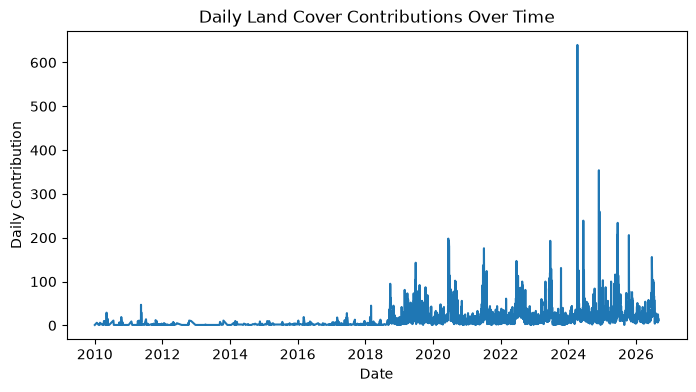

In [45]:
data_by_day = data[['SiteId', 'MeasuredDate']].groupby(['MeasuredDate'], as_index=False).count()

plt.figure(figsize=(8,4))
plt.plot(data_by_day['MeasuredDate'], data_by_day['SiteId'])
plt.xlabel("Date")
plt.ylabel("Daily Contribution")
plt.title("Daily Land Cover Contributions Over Time")
plt.show()

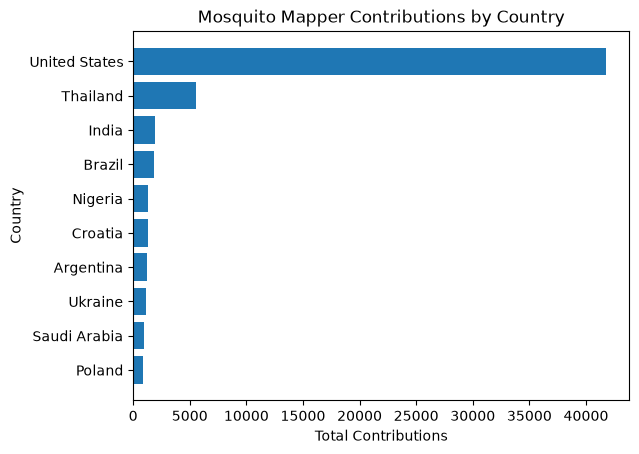

In [46]:
data_by_county = data[['SiteId', 'CountryName']].groupby(['CountryName'], as_index=False).count().sort_values(by='SiteId').tail(10)

plt.barh(data_by_county['CountryName'], data_by_county['SiteId'])
plt.xlabel("Total Contributions")
plt.ylabel("Country")
plt.title("Mosquito Mapper Contributions by Country")
plt.show()

A powerful feature of the Land Cover dataset is that users submit pictures of the area. Let's view some of these images.

In [47]:
# Get the first observation where all photos were submitted
entry = data.dropna(subset=['DownwardPhotoUrl', 'EastPhotoUrl', 'NorthPhotoUrl', 'SouthPhotoUrl', 'WestPhotoUrl', 'UpwardPhotoUrl',
                            'Feature1PhotoUrl', 'Feature2PhotoUrl', 'Feature3PhotoUrl', 'Feature4PhotoUrl']).head(1)

url_list = []
col_list = []

for col in entry.columns:
  if 'Url' in col:
    print(f'{col}: {entry[col].values[0]}')
    url_list.append(entry[col].values[0])
    col_list.append(col)

display(entry)

DownwardPhotoUrl: https://data.globe.gov/system/photos/2026/08/31/5139503/original.jpg
EastPhotoUrl: https://data.globe.gov/system/photos/2026/08/31/5139499/original.jpg
Feature1PhotoUrl: https://data.globe.gov/system/photos/2026/08/31/5139504/original.jpg
Feature2PhotoUrl: https://data.globe.gov/system/photos/2026/08/31/5139505/original.jpg
Feature3PhotoUrl: https://data.globe.gov/system/photos/2026/08/31/5139506/original.jpg
Feature4PhotoUrl: https://data.globe.gov/system/photos/2026/08/31/5139507/original.jpg
NorthPhotoUrl: https://data.globe.gov/system/photos/2026/08/31/5139498/original.jpg
SouthPhotoUrl: https://data.globe.gov/system/photos/2026/08/31/5139500/original.jpg
UpwardPhotoUrl: https://data.globe.gov/system/photos/2026/08/31/5139502/original.jpg
WestPhotoUrl: https://data.globe.gov/system/photos/2026/08/31/5139501/original.jpg


,CountryCode,CountryName,Elevation,DataSource,DownwardCaption,DownwardExtraData,DownwardPhotoUrl,DryGround,EastCaption,EastClassifications,EastExtraData,EastPhotoUrl,Feature1Caption,Feature1ExtraData,Feature1PhotoUrl,Feature2Caption,Feature2ExtraData,Feature2PhotoUrl,Feature3Caption,Feature3ExtraData,Feature3PhotoUrl,Feature4Caption,Feature4ExtraData,Feature4PhotoUrl,FieldNotes,GlobeTeams,LandCoverId,LeavesOnTrees,LocationAccuracyM,LocationMethod,MeasuredAt,MeasurementElevation,MeasurementLatitude,MeasurementLongitude,MucCode,MucDescription,MucDetails,Muddy,NorthCaption,NorthClassifications,NorthExtraData,NorthPhotoUrl,RainingSnowing,SnowIce,SouthCaption,SouthClassifications,SouthExtraData,SouthPhotoUrl,StandingWater,UpwardCaption,UpwardExtraData,UpwardPhotoUrl,Userid,WestCaption,WestClassifications,WestExtraData,WestPhotoUrl,OrganizationId,OrganizationName,Protocol,SiteId,SiteName,geometry,MeasuredDate
6,USA,United States,267.9,GLOBE Observer App,NaN,NaN,https://data.globe.gov/system/photos/2026/08/3...,true,NaN,NaN,NaN,https://data.globe.gov/system/photos/2026/08/3...,NaN,"((compassData.heading: 260, compassData.horizo...",https://data.globe.gov/system/photos/2026/08/3...,NaN,"((compassData.heading: 336, compassData.horizo...",https://data.globe.gov/system/photos/2026/08/3...,NaN,"((compassData.heading: 279, compassData.horizo...",https://data.globe.gov/system/photos/2026/08/3...,NaN,"((compassData.heading: 289, compassData.horizo...",https://data.globe.gov/system/photos/2026/08/3...,NaN,NaN,94654,true,10,automatic,2026-08-31 18:43:00,269.7,39.8439,-86.3833,NaN,NaN,,false,NaN,NaN,NaN,https://data.globe.gov/system/photos/2026/08/3...,false,false,NaN,NaN,NaN,https://data.globe.gov/system/photos/2026/08/3...,false,NaN,NaN,https://data.globe.gov/system/photos/2026/08/3...,126092159,NaN,NaN,NaN,https://data.globe.gov/system/photos/2026/08/3...,17043304,United States of America Citizen Science,land_covers,361103,16SEK527106,POINT (-86.38402 39.84378),2026-08-31


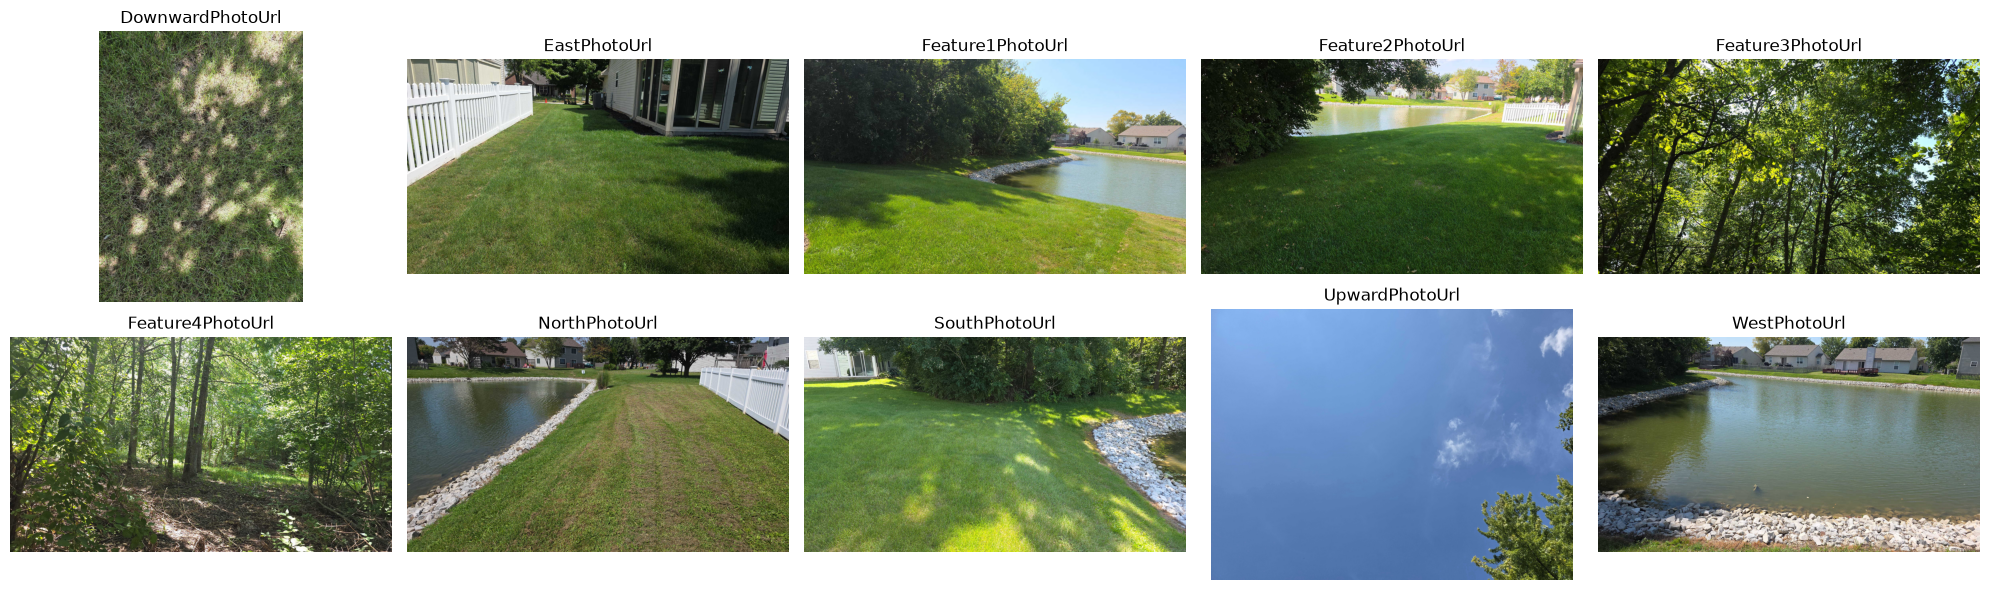

In [48]:
# Plot all of the images
plt.figure(figsize=(20, 6))

for i, (url, title) in enumerate(zip(url_list, col_list)):
    response = requests.get(url)
    img = Image.open(BytesIO(response.content))

    # Create plot with 2 rows, 5 columns
    plt.subplot(2, 5, i + 1)
    plt.imshow(img)
    plt.title(title)
    plt.axis('off')

plt.tight_layout()
plt.show()